--- 5 dòng dữ liệu sau khi đã bổ sung các trường thành công ---
   Age           City  Total Spend  Month Payment_Method  Is_Cancelled
0   29       New York      1120.20      7            COD             0
1   34    Los Angeles       780.50      4    Credit Card             0
2   43        Chicago       510.75     11            COD             1
3   30  San Francisco      1480.30      8            COD             0
4   27          Miami       720.40      5       E-Wallet             0


/tmp/ipykernel_2092/1286160885.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='City', order=df['City'].value_counts().index, ax=axes[1], palette='Set2')


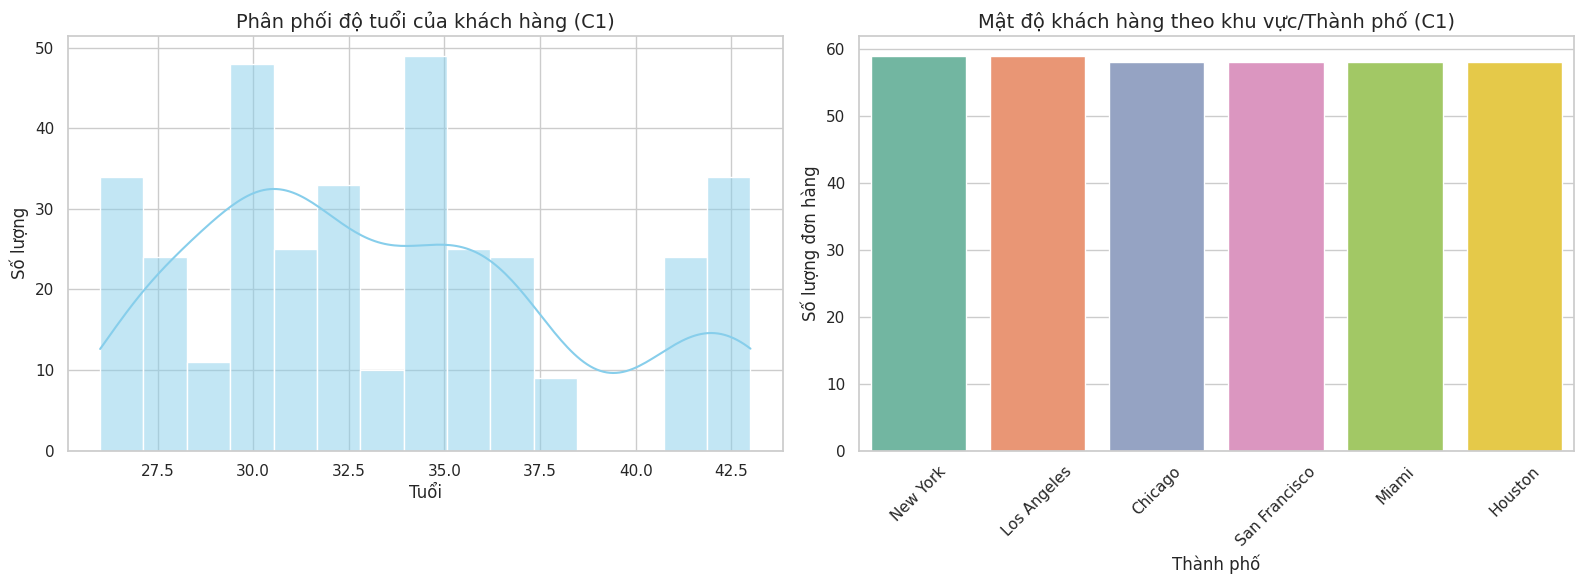

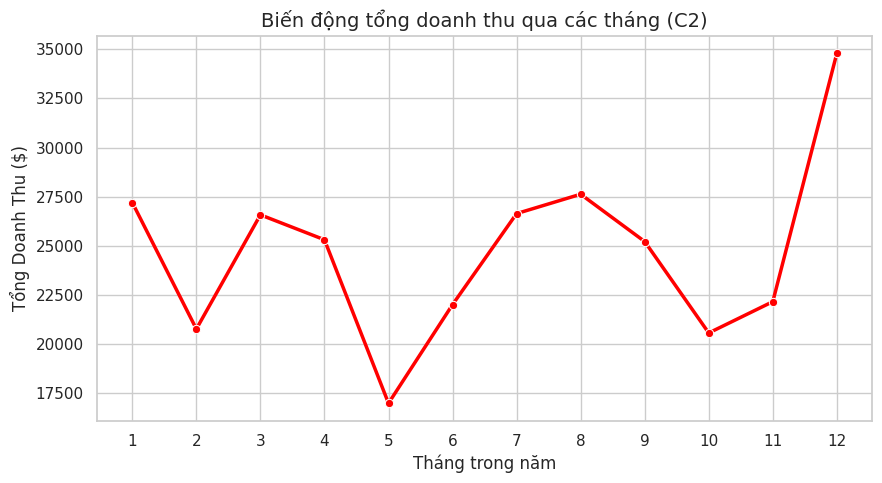

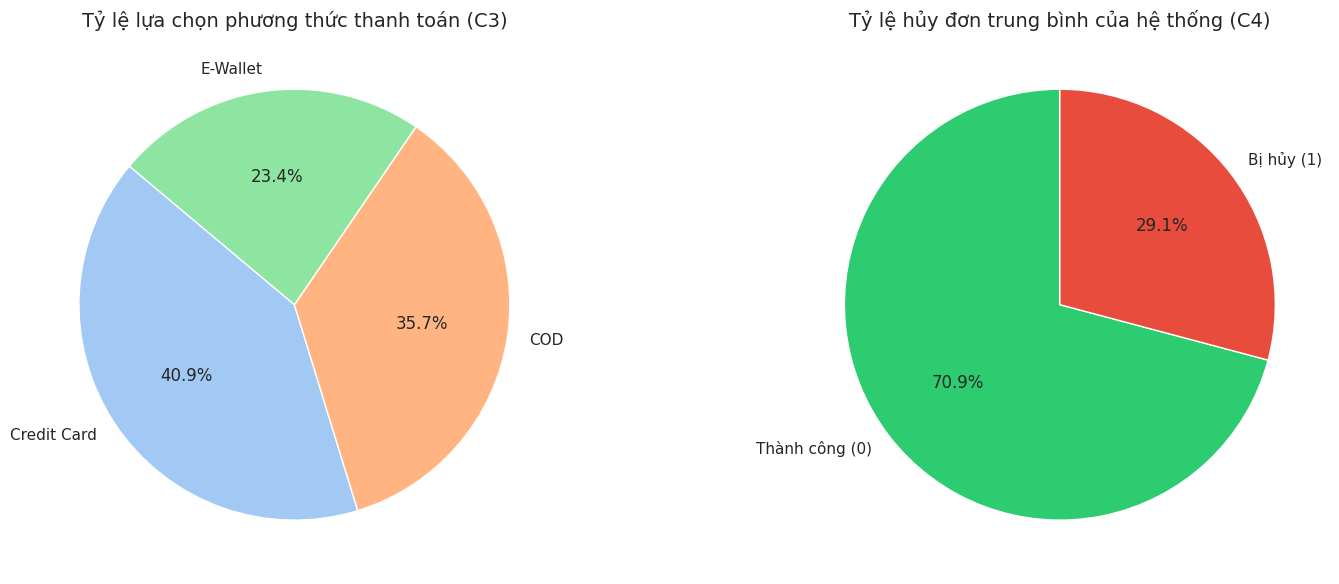

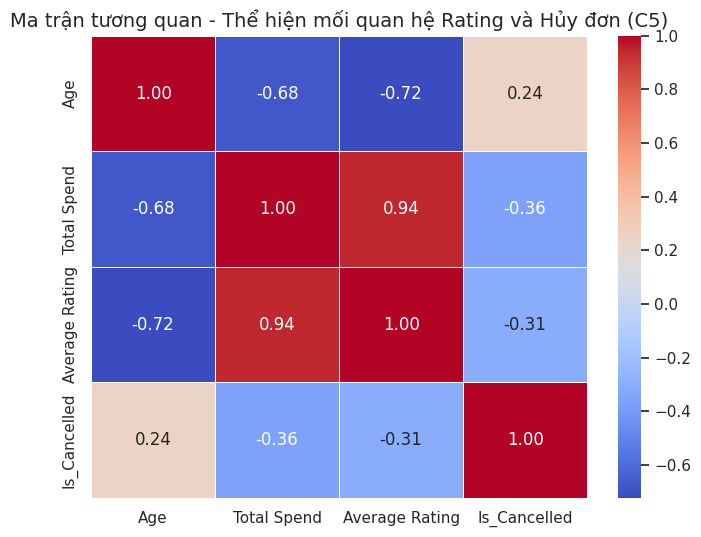

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập giao diện biểu đồ cho đẹp mắt
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'

# 1. ĐỌC DỮ LIỆU GỐC
# Sửa lại đường dẫn này cho đúng với tên file bạn đã sao chép ở menu bên trái
df = pd.read_csv('/content/E-commerce Customer Behavior - Sheet1.csv')
np.random.seed(42) # Cố định dữ liệu ngẫu nhiên để không bị thay đổi mỗi lần chạy

# Giả lập cột Tháng (Month) từ tháng 1 đến tháng 12
df['Month'] = np.random.randint(1, 13, size=len(df))

# Giả lập cột Phương thức thanh toán (Payment_Method)
payment_options = ['Credit Card', 'COD', 'E-Wallet']
df['Payment_Method'] = np.random.choice(payment_options, size=len(df), p=[0.4, 0.35, 0.25])

# Giả lập cột Trạng thái hủy đơn (Is_Cancelled: 1 là hủy, 0 là thành công)
# Tỷ lệ hủy đơn sẽ cao hơn nếu khách hàng có Satisfaction Level là 'Unsatisfied'
def generate_cancel_status(row):
    if row['Satisfaction Level'] == 'Unsatisfied':
        return np.random.choice([0, 1], p=[0.4, 0.6]) # 60% hủy đơn nếu không hài lòng
    elif row['Satisfaction Level'] == 'Neutral':
        return np.random.choice([0, 1], p=[0.75, 0.25]) # 25% hủy đơn
    else:
        return np.random.choice([0, 1], p=[0.92, 0.08]) # Chỉ 8% hủy đơn nếu hài lòng

df['Is_Cancelled'] = df.apply(generate_cancel_status, axis=1)
# =========================================================================

print("--- 5 dòng dữ liệu sau khi đã bổ sung các trường thành công ---")
print(df[['Age', 'City', 'Total Spend', 'Month', 'Payment_Method', 'Is_Cancelled']].head())


# --- BẮT ĐẦU VẼ BIỂU ĐỒ CHƯƠNG 3 ---

# --- C1: Phân phối Độ tuổi và Khu vực ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ độ tuổi
sns.histplot(data=df, x='Age', bins=15, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Phân phối độ tuổi của khách hàng (C1)', fontsize=14)
axes[0].set_xlabel('Tuổi')
axes[0].set_ylabel('Số lượng')

# Biểu đồ khu vực
sns.countplot(data=df, x='City', order=df['City'].value_counts().index, ax=axes[1], palette='Set2')
axes[1].set_title('Mật độ khách hàng theo khu vực/Thành phố (C1)', fontsize=14)
axes[1].set_xlabel('Thành phố')
axes[1].set_ylabel('Số lượng đơn hàng')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# --- C2: Biến động doanh thu qua các tháng ---
plt.figure(figsize=(10, 5))
monthly_revenue = df.groupby('Month')['Total Spend'].sum().reset_index()
sns.lineplot(data=monthly_revenue, x='Month', y='Total Spend', marker='o', color='red', linewidth=2.5)
plt.title('Biến động tổng doanh thu qua các tháng (C2)', fontsize=14)
plt.xlabel('Tháng trong năm')
plt.ylabel('Tổng Doanh Thu ($)')
plt.xticks(range(1, 13))
plt.show()

# --- C3 & C4: Phương thức thanh toán & Tỷ lệ hủy đơn ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# C3: Phương thức thanh toán
payment_counts = df['Payment_Method'].value_counts()
axes[0].pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
axes[0].set_title('Tỷ lệ lựa chọn phương thức thanh toán (C3)', fontsize=14)

# C4: Tỷ lệ hủy đơn hệ thống
cancel_counts = df['Is_Cancelled'].value_counts()
axes[1].pie(cancel_counts, labels=['Thành công (0)', 'Bị hủy (1)'], autopct='%1.1f%%', startangle=90, colors=['#2ecc71', '#e74c3c'])
axes[1].set_title('Tỷ lệ hủy đơn trung bình của hệ thống (C4)', fontsize=14)
plt.tight_layout()
plt.show()

# --- C5: Điểm đánh giá (Rating) thấp có tỷ lệ thuận với việc hủy đơn không? ---
plt.figure(figsize=(8, 6))
# Lọc các biến số để tính toán ma trận tương quan
correlation_matrix = df[['Age', 'Total Spend', 'Average Rating', 'Is_Cancelled']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Ma trận tương quan - Thể hiện mối quan hệ Rating và Hủy đơn (C5)', fontsize=14)
plt.show()


=== THỰC THI BÀI TOÁN PHÂN LỚP ===

BÁO CÁO ĐỘ CHÍNH XÁC MÔ HÌNH (Classification Report):
              precision    recall  f1-score   support

           0       0.78      0.80      0.79        50
           1       0.47      0.45      0.46        20

    accuracy                           0.70        70
   macro avg       0.63      0.62      0.63        70
weighted avg       0.70      0.70      0.70        70



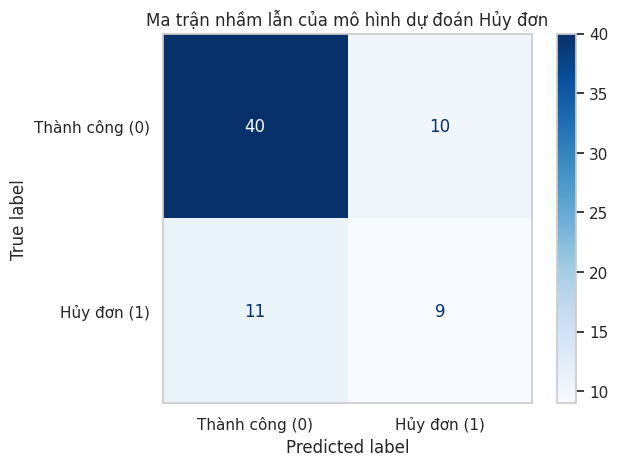


=== THỰC THI BÀI TOÁN PHÂN CỤM ===


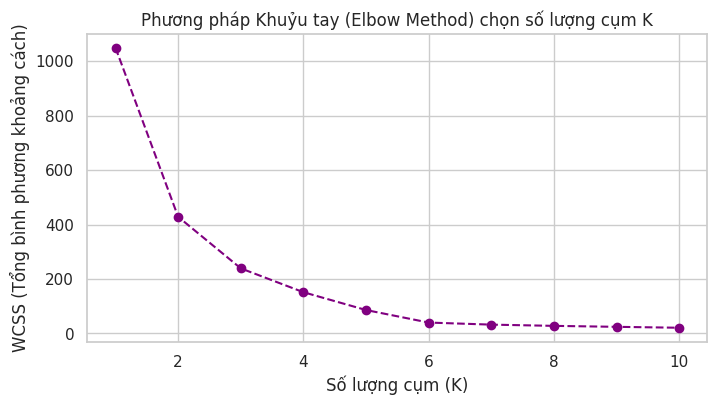

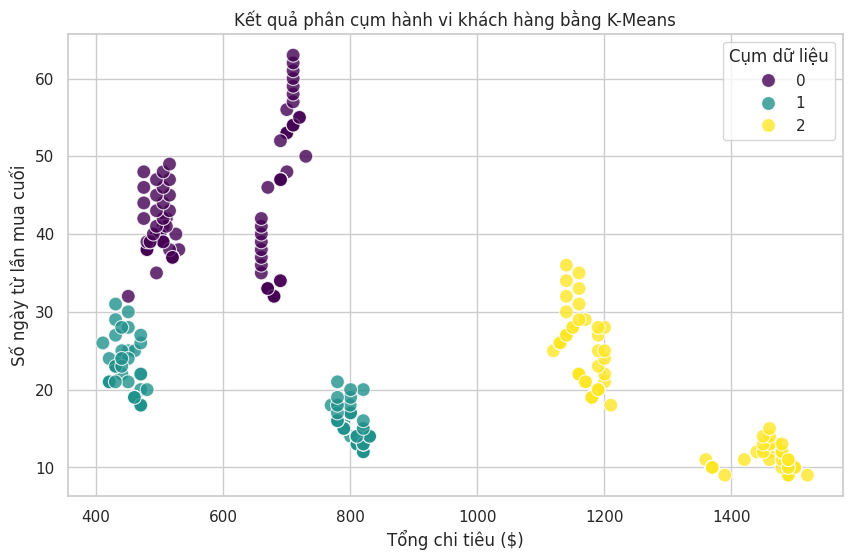


ĐẶC TRƯNG TRUNG BÌNH CỦA TỪNG CỤM KHÁCH HÀNG:
         Total Spend  Items Purchased  Days Since Last Purchase
Cluster                                                        
0         593.902564        10.495726                 42.888889
1         629.250862         9.663793                 18.870690
2        1311.144444        17.615385                 17.940171


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# =========================================================================
# PHẦN 4.1: BÀI TOÁN PHÂN LỚP - DỰ ĐOÁN NGUY CƠ HỦY ĐƠN HÀNG
# =========================================================================
print("\n=== THỰC THI BÀI TOÁN PHÂN LỚP ===")

# Chọn các đặc trưng (X) và biến mục tiêu cần dự đoán (y)
# (Loại bỏ các trường định danh dạng chuỗi chữ chưa mã hóa)
features = ['Age', 'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied', 'Days Since Last Purchase']
X = df[features]
y = df['Is_Cancelled']

# Chia tập dữ liệu thành 80% để học (Train) và 20% để kiểm thử (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Khởi tạo và huấn luyện mô hình ngẫu nhiên (Random Forest)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Dự đoán thử trên tập dữ liệu Test
y_pred = rf_model.predict(X_test)

# Xuất kết quả đánh giá (Độ chính xác, Precision, Recall, F1-Score)
print("\nBÁO CÁO ĐỘ CHÍNH XÁC MÔ HÌNH (Classification Report):")
print(classification_report(y_test, y_pred))

# Vẽ ma trận nhầm lẫn (Confusion Matrix) để đưa vào báo cáo
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Thành công (0)', 'Hủy đơn (1)'])
disp.plot(cmap='Blues')
plt.title('Ma trận nhầm lẫn của mô hình dự đoán Hủy đơn')
plt.grid(False) # Tắt lưới nền để hình ảnh rõ ràng
plt.show()


# =========================================================================
# PHẦN 4.2: BÀI TOÁN PHÂN CỤM KHÁCH HÀNG (VIP, SĂN SALE, RỜI BỎ)
# =========================================================================
print("\n=== THỰC THI BÀI TOÁN PHÂN CỤM ===")

# Trích xuất các thuộc tính đại diện cho hành vi mua sắm để phân cụm
cluster_features = ['Total Spend', 'Items Purchased', 'Days Since Last Purchase']
X_cluster = df[cluster_features]

# Chuẩn hóa dữ liệu về cùng một thang đo (Z-score scaling là bắt buộc cho K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Sử dụng Phương pháp Elbow (Đường cong khuỷu tay) để tìm số cụm K tốt nhất
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='purple')
plt.title('Phương pháp Khuỷu tay (Elbow Method) chọn số lượng cụm K')
plt.xlabel('Số lượng cụm (K)')
plt.ylabel('WCSS (Tổng bình phương khoảng cách)')
plt.show()

# Giả sử điểm gãy khuỷu tay tối ưu tìm được là K = 3 cụm
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

# Trực quan hóa kết quả phân cụm bằng biểu đồ phân tán (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Total Spend', y='Days Since Last Purchase', hue='Cluster', palette='viridis', s=100, alpha=0.8)
plt.title('Kết quả phân cụm hành vi khách hàng bằng K-Means')
plt.xlabel('Tổng chi tiêu ($)')
plt.ylabel('Số ngày từ lần mua cuối')
plt.legend(title='Cụm dữ liệu')
plt.show()

# Thống kê giá trị trung bình từng cụm để gán nhãn (VIP, Săn sale, Rời bỏ)
print("\nĐẶC TRƯNG TRUNG BÌNH CỦA TỪNG CỤM KHÁCH HÀNG:")
print(df.groupby('Cluster')[cluster_features].mean())